# Function Approximation using a Multi-Layer Perceptron

**Authors:** Natalia Sperczyńska, 278444 and Weronika Łaszkiewicz, 278434 \
**Course:** Artificial Intelligence 1, W11MIP-SI0044W\
**Date:** 14 April 2026


**Repository:** [github.com/natalia0sperczynska/MLPs-Universal-Approximators](https://github.com/natalia0sperczynska/MLPs-Universal-Approximators) — full code available in `multi_layer_perceptrons.ipynb` notebook.

**Note:** The requirement to submit a PDF report was only visible after clicking 
the submit button. For the best experience, we encourage viewing this work as a 
Jupyter notebook via the repository link above, as the PDF cannot render the 
convergence animation (GIF) and some plots may appear differently.

**Task**: Write a piece of code and use it to perform numerical experiments that empirically
demonstrate that Multi-Layer Perceptrons  can approximate a large class of continuous functions.


## Approach

This challenge approach is based on the work of R. Potluri:
[*Neural Networks Can Approximate Almost Any Continuous Function*](https://medium.com/@rohitpotluri1221/neural-networks-can-approximate-almost-any-continuous-function-5d9f09e76fe2).

We followed Potluri's implementation adopting his MLP architecture
(two hidden tanh layers built with `torch.nn.Sequential`), and his animation approach
of snapshotting predictions during training to visualise convergence.


## What is a Multi-Layer Perceptron?

An MLP is a type of feedforward neural network consisting of at least three layers: an input layer, one or more hidden layers, and an output layer. Each neuron in one layer is fully connected to every neuron in the next layer.

The MLP learns by adjusting the weights of these connections to minimize the error between its predictions and the true values, using backpropagation [https://en.wikipedia.org/wiki/Multilayer_perceptron].

In this challange we'll use MLPs for regression, the network takes a single value $x$ as input and outputs an approximation of $f(x)$.


## Imports and Parameters Setup

In [1]:
#!pip install requirements.txt
import numpy as np
import base64
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from matplotlib import animation
from pathlib import Path
from IPython.display import HTML

seed = 777  # so we can reproduce the same results each time we run the code
np.random.seed(seed)
torch.manual_seed(seed)

Use GPU if available, which can significantly speed up training for larger models and datasets. In this case, it's not strictly necessary due to the small scale of our experiment, but it's good practice to include it. [https://docs.pytorch.org/docs/stable/notes/cuda.html]

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Target Functions

We decided to test the MLP on six functions chosen to cover a wide variety of behaviours. They were generated using a Gemini Pro prompt:

> Create a Python dictionary TARGET_FUNCTIONS that will contain a diverse set of mathematical functions to test MLP approximation. Include periodic, exponential decay, non-differentiable and non-linear types. Each should be a tuple of a lambda function and an x-axis rang


The sawtooth function is intentionally included as a negative control. Because it is discontinuous, the Universal Approximation Theorem does not guarantee the MLP can fit it well.

In [3]:
# name, function, and range pairs to test the MLP's approximation capabilities
TARGET_FUNCTIONS = {
    "sin(x)": (lambda x: np.sin(x), (-6, 6)), # smooth, periodic
    "cos(2x)·e^(-x²/4)": (lambda x: np.cos(2 * x) * np.exp(-x ** 2 / 4), (-4, 4)), # damped oscillation
    "|x|": (lambda x: np.abs(x), (-3, 3)), # non-differentiable at 0
    "x²·sin(x)": (lambda x: x ** 2 * np.sin(x), (-5, 5)),# non-linear
    "tanh(5x)": (lambda x: np.tanh(5 * x), (-2, 2)), # sharp
    "sawtooth-like": (lambda x: x - np.floor(x), (0, 4)), # discontinuous negative control
}

## Generating Training Data

For each function we sample $n$ evenly-spaced points from its domain to form $(x_i,\, f(x_i))$ pairs. The MLP never sees the formula and only from these discrete samples it must learn to reproduce $f$. Real-world data often includes noise, but becasue our primary objective is to demonstrate the Universal Approximation Theorem we did not include it in our code.

In [4]:
def generate_data(function, n=256, x_min=-2.0, x_max=2.0):
    x = np.linspace(x_min, x_max, n).reshape(-1, 1).astype(np.float32)
    # generate n points between x_min and x_max, reshape to be a column vector, and convert to float32 for better performance with PyTorch

    y = function(x).astype(np.float32)

    x_t = torch.tensor(x, device=device)
    y_t = torch.tensor(y, device=device)
    return x, y, x_t, y_t

## Model Creation and Training

Following the R.Potluri article and the pytorch documentation we start by defining a simple MLP with two hidden layers of configurable width.
We define our neural network by subclassing nn.Module, and initialize the neural network layers in __init__. Every nn.Module subclass implements the operations on input data in the forward method. Parameter `hidden` determines the "width" of the network, meaning how many neurons there are in the hidden layers [https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html].


In [5]:
class MLP(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),  # input layer to first hidden layer
            nn.Tanh(),  # activation function to introduce non-linearity
            nn.Linear(hidden, hidden),  # first hidden layer to second hidden layer
            nn.Tanh(),
            nn.Linear(hidden, 1),  # output layer, takes signals from 32 neurons and squishes them back to 1 value
        )

    def forward(self, x):
        return self.net(x)


Print to check if the model was created correctly.

In [6]:
model = MLP().to(device)
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Model Training

Training the MLP starts by defining a loss function. We decided to use MSELoss, because according to the documentation it's standard for regression tasks [https://docs.pytorch.org/cppdocs/api/nn/loss.html].

For the optimizer we chose Adam (an adaptive gradient descent method), because it's the one used in the  R.Potluri article, and after additional reasarch we concluded that it is a correct choice. Adam adjusts the learning rate per parameter and is one of the most widely used optimizers for regression [https://doi.org/10.3390/electronics12143071].

To train a model we also need a training loop that iteratively updates the model's weights to minimize the loss [https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html]. A fixed step counter is used rather than a convergence condition because in
real problems the loss rarely reaches exactly zero.

During training we snapshot the predictions every `record_every` steps so we can animate the convergence afterwards.

In [7]:
def train(model, x_t, y_t, steps=2000, lr=1e-3, record_every=25):
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    # we use the mean square error (MSELoss) function to measure how far the model predictions deviate from the true function
    loss_fn = nn.MSELoss()

    history = {
        "step": [],
        "loss": [],
        "preds": []  # snapshots
    }

    for step in range(steps + 1):
        model.train()
        pred = model(x_t)
        loss = loss_fn(pred, y_t)

        opt.zero_grad()  # clears gradients from the previous iteration
        loss.backward()  # backpropagation: compute gradients
        opt.step()  # gradient descent: update weights

        if step % record_every == 0:
            model.eval()
            with torch.no_grad():
                pred_eval = model(x_t).detach().cpu().numpy()
            history["step"].append(step)
            history["loss"].append(float(loss.detach().cpu().item()))
            history["preds"].append(pred_eval)

    return model, history


## Convergence Animation

We first focus on `sin(x)` and animate how the MLP's prediction evolves over
3000 training steps. The network starts from a random curve and gradually
converges to the true function as the loss decreases,
demonstrating the learning process.

In [8]:
def animate_training(history, x, y, fn_name="Function", gif_path="mlp_convergence.gif"):
    fig, ax = plt.subplots()
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    # true curve
    ax.plot(x.flatten(), y.flatten(), linewidth=2, label=f"True: {fn_name}", color='royalblue', alpha=0.7)
    # pred curve
    pred_line, = ax.plot(x.flatten(), history["preds"][0].flatten(), linewidth=2, label="MLP prediction",
                         color='crimson', linestyle='--')
    ax.legend()

    def update(frame_idx):
        pred = history["preds"][frame_idx]
        pred_line.set_ydata(pred.flatten())
        ax.set_title(
            f"MLP learning {fn_name} | step {history['step'][frame_idx]} | loss {history['loss'][frame_idx]:.4e}")
        return (pred_line,)

    anim = animation.FuncAnimation(fig, update, frames=len(history["preds"]), interval=80, blit=True)
    anim.save(gif_path, writer="pillow")
    plt.close(fig)
    return gif_path  # html path returned


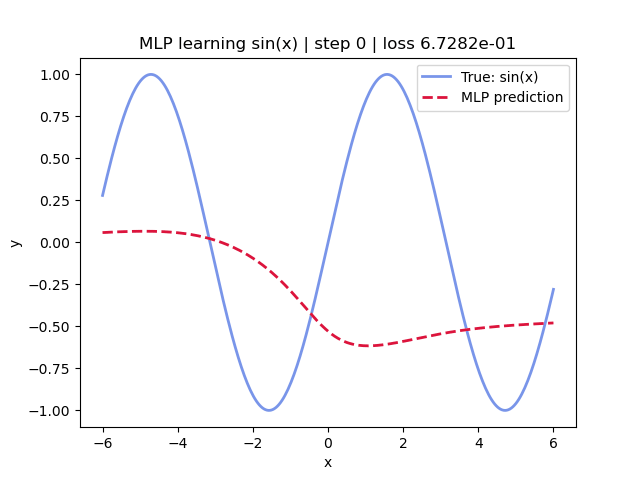

In [9]:
fn_sin, x_min, x_max = TARGET_FUNCTIONS["sin(x)"][0], *TARGET_FUNCTIONS["sin(x)"][1]
x_s, y_s, x_t_s, y_t_s = generate_data(fn_sin, n=300, x_min=x_min, x_max=x_max)

model_sin = MLP(hidden=32)
model_sin, hist_sin = train(model_sin, x_t_s, y_t_s, steps=3000, lr=1e-3, record_every=50)

gif_path = animate_training(hist_sin, x_s, y_s, fn_name="sin(x)", gif_path="mlp_convergence.gif")

# Display GIF inline
data = Path(gif_path).read_bytes()
b64 = base64.b64encode(data).decode("utf-8")
HTML(f'<img src="data:image/gif;base64,{b64}" style="max-width:100%" />')

## Experiment: Effect of Network Width

The Universal Approximation Theorem states that a network with sufficient
capacity can approximate any continuous function [https://en.wikipedia.org/wiki/Universal_approximation_theorem]. We decided to check what does "sufficient"
mean in practice. We used a fixed `sin(x)` functioned and varied the number
of neurons in the hidden layers (the network width) from 4 to 64,
measuring the MSE at each value.

In [10]:
widths = [4, 8, 16, 32, 64]
fn_sin = TARGET_FUNCTIONS["sin(x)"][0]
x_w, y_w, x_tw, y_tw = generate_data(fn_sin, n=300, x_min=-2, x_max=2)

width_results = {}

print(f"{'Width':>8}{'MSE':>12}")
print("-" * 32)
for h in widths:
    m = MLP(hidden=h)
    m, _ = train(m, x_tw, y_tw, steps=3000, lr=1e-3, record_every=3000)
    with torch.no_grad():
        pred = m(x_tw).detach().cpu().numpy()
    mse = float(np.mean((pred - y_w) ** 2))
    width_results[h] = (pred, mse)
    print(f"{h:>8}  {mse:>12.6f}")


   Width         MSE
--------------------------------
       4      0.001262
       8      0.000486
      16      0.000193
      32      0.000054
      64      0.000026


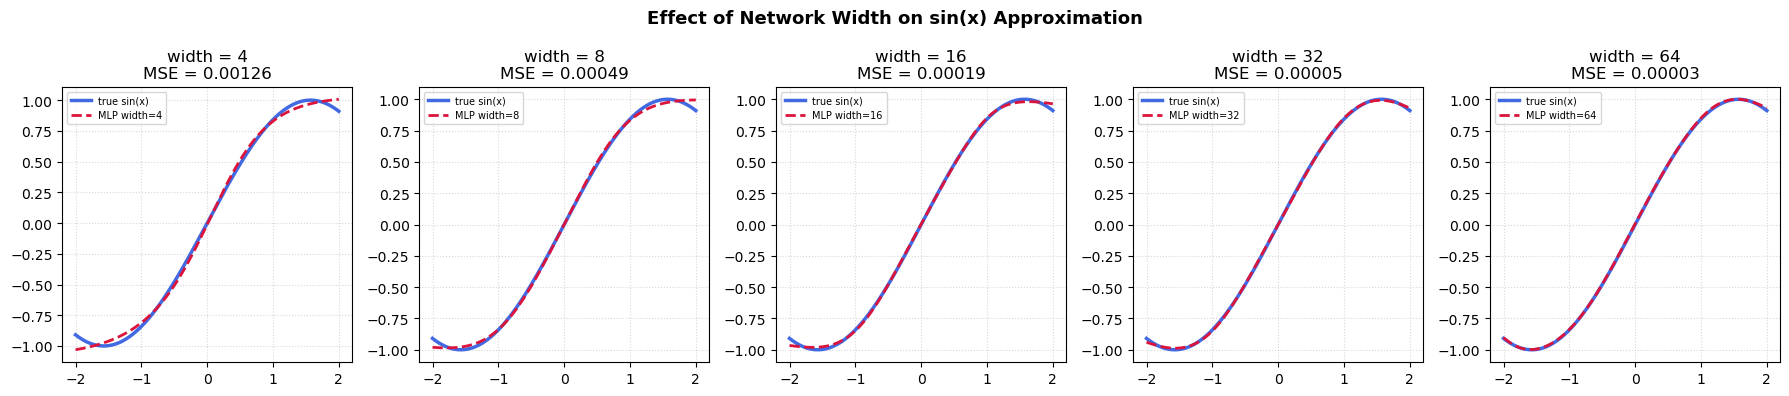

In [11]:
#width vs fit quality
fig, axes = plt.subplots(1, len(widths), figsize=(18, 4))
fig.suptitle("Effect of Network Width on sin(x) Approximation", fontsize=13, fontweight="bold")

for ax, h in zip(axes, widths):
    pred, mse = width_results[h]
    ax.plot(x_w, y_w, lw=2.5, color="royalblue", label="true sin(x)")
    ax.plot(x_w, pred, lw=2, color="crimson", linestyle="--", label=f"MLP width={h}")
    ax.set_title(f"width = {h}\nMSE = {mse:.5f}")
    ax.legend(fontsize=7)
    ax.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig("width_experiment.png", dpi=140, bbox_inches="tight")
plt.show()

**Observations:** The results show that as network width increases, the MLP approximates `sin(x)` more accurately. We can observe this both in the plots and in the decreasing MSE. Narrow networks
lack the capacity to capture the complex patterns in the data, while wider ones converge
closely to the true curve. This empirically confirms that greater model
capacity leads to better approximation.

## All Target Functions

We now train a separate MLP (width=32, 2500 steps) on each of our six target
functions and plot the results. The last function (the sawtooth) serves as a
negative control: since it is discontinuous, the theorem's guarantees do
not apply and we expect the MLP to struggle.

In [12]:
def visualize_results(trained):
    num_fns = len(trained)
    fig, axes = plt.subplots(nrows=num_fns, ncols=1, figsize=(8, 4 * num_fns))
    fig.suptitle("True vs MLP", fontsize=16)

    if num_fns == 1: axes = [axes]

    for i, (name, x, y, pred) in enumerate(trained):
      ax = axes[i]
      mse = float(np.mean((pred - y) ** 2))

      ax.plot(x.flatten(), y.flatten(), label="True Function", color='royalblue',
              linewidth=2.5, alpha=0.7)
      ax.plot(x.flatten(), pred.flatten(), label="MLP Approximation", color='crimson',
              linewidth=2, linestyle='--')

      ax.set_title(f"Target: {name}  |  MSE = {mse:.2e}", fontsize=14)
      ax.legend(loc='upper right')
      ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout(rect=(0, 0.03, 1, 0.97))
    plt.savefig("function_approximations.png", dpi=140)
    plt.show()

In [13]:
def train_all_functions():
    trained = []
    for name, (fn, (x_min, x_max)) in TARGET_FUNCTIONS.items():
        x_np, y_np, x_t, y_t = generate_data(fn, n=300, x_min=x_min, x_max=x_max)

        model = MLP(hidden=32).to(device)
        model, _ = train(model, x_t, y_t, steps=2500, lr=1e-3, record_every=2500)

        with torch.no_grad():
            pred = model(x_t).detach().cpu().numpy()
        trained.append((name, x_np, y_np, pred))

    return trained

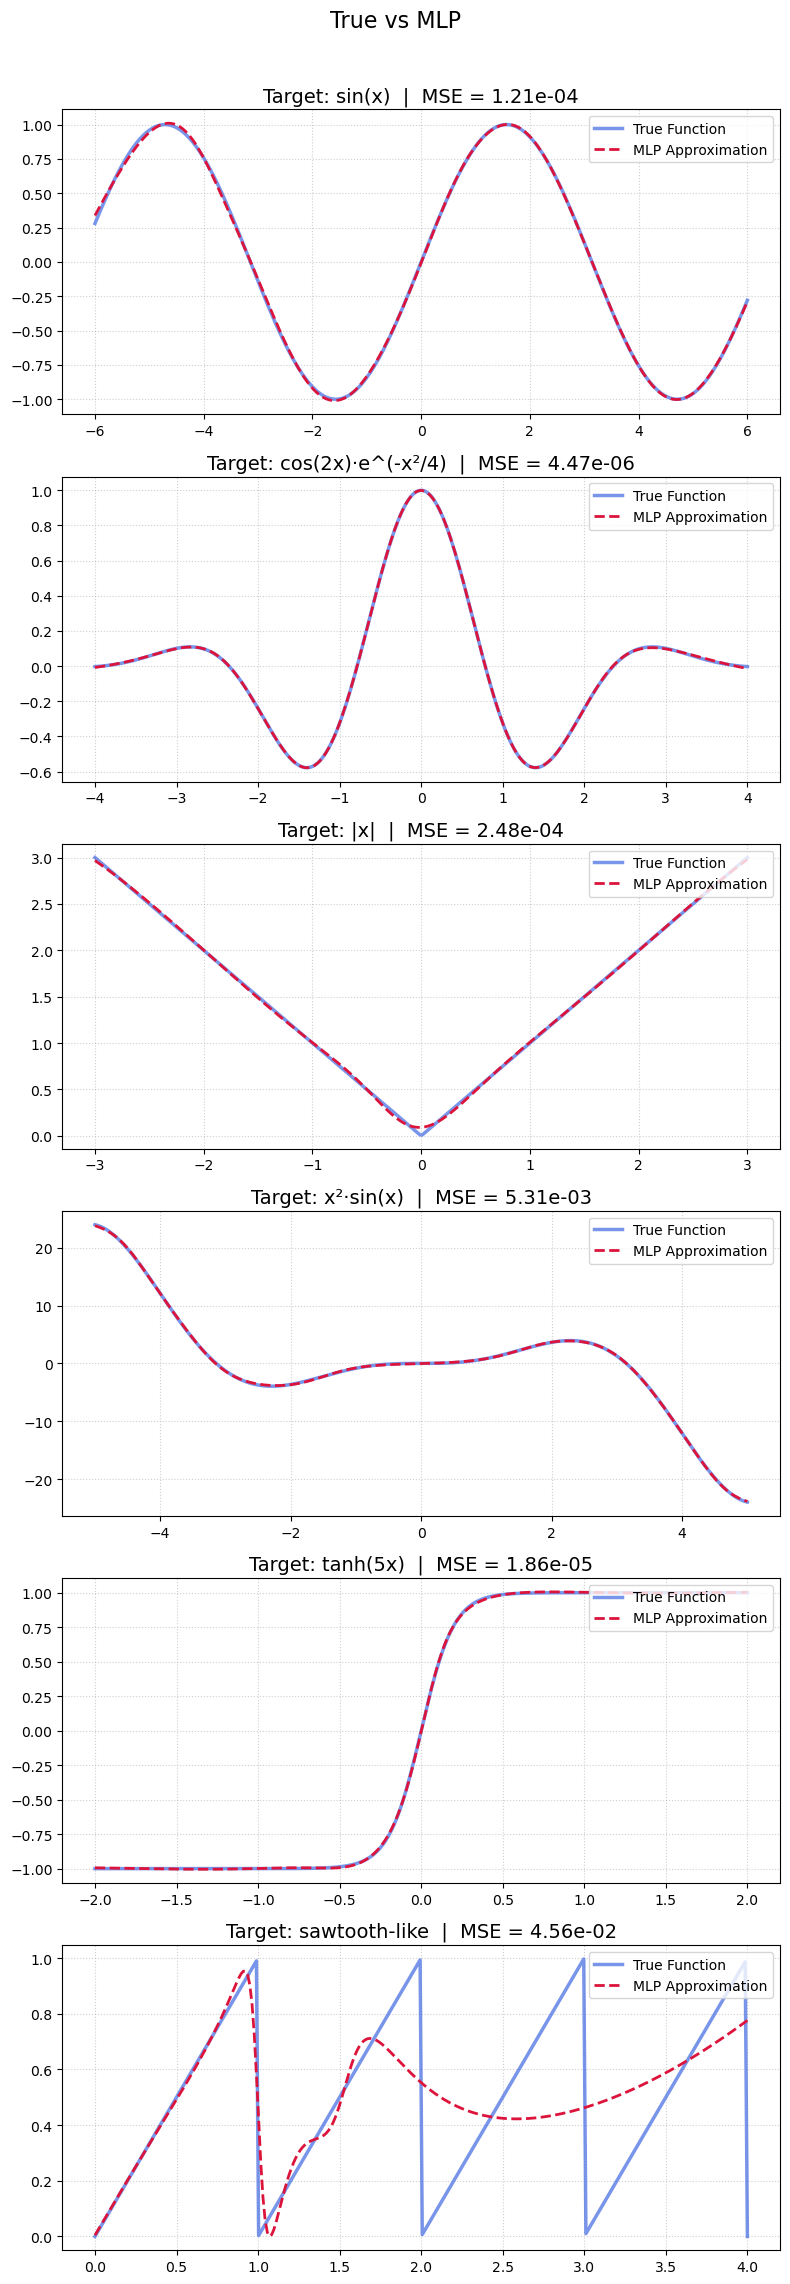

In [14]:
trained_data = train_all_functions()
visualize_results(trained_data)

## Conclusion

The experiments empirically support the Universal Approximation Theorem:
an MLP with non-linear activations can approximate any continuous function on
a compact domain.

Across the five continuous target functions tested  (periodic, damped,
non-differentiable, and step-like behaviours) the MLP produced accurate
approximations with low MSE. Notably, even `|x|`, which is non-differentiable
at the origin, was approximated well, though the smooth nature of the tanh
activation resulted in a slightly rounded corner at x=0 rather than a sharp point.

The width experiment confirmed that model capacity is a key factor:
increasing the number of neurons per hidden layer consistently reduced the
approximation error.

The sawtooth function, included as a negative control, was not well approximated.
The MLP produced a smoothed output that failed to capture the sharp discontinuities,
behaviour consistent with the theorem, which applies exclusively to continuous functions.

## References

**Primary inspiration**

R. Potluri, *Neural Networks Can Approximate Almost Any Continuous Function*, Medium, 2024.
[[article]](https://medium.com/@rohitpotluri1221/neural-networks-can-approximate-almost-any-continuous-function-5d9f09e76fe2)
[[notebook]](https://github.com/rohitpotluri/medium/blob/main/Neural_Networks.ipynb)

**PyTorch Documentation**

- *Build the Neural Network* — https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html
- *Optimization Loop* — https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html
- *CUDA semantics* — https://docs.pytorch.org/docs/stable/notes/cuda.html

**Additional reading**

- S. Soni, *PyTorch Neural Networks: A Complete Guide*, Medium.
[[link]](https://medium.com/@sachinsoni600517/pytorch-neural-networks-a-complete-guide-059e236559ff)
- M. Nazari, *Building a Simple MLP from Scratch using PyTorch*, Medium.
[[link]](https://medium.com/@mn05052002/building-a-simple-mlp-from-scratch-using-pytorch-7d50ca66512b)
- Wikipedia, *Multilayer perceptron* — https://en.wikipedia.org/wiki/Multilayer_perceptron
- Wikipedia, *Universal Approximation Theorem* - https://en.wikipedia.org/wiki/Universal_approximation_theorem

**Tools**

- Google Gemini Pro — used for generating the set of diverse target functions
  and assisting with visualisation logic.